In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import math
%matplotlib inline

In [3]:
data = pd.read_csv("exam.csv")
X_train = data[['Exam1', 'Exam2']].values
y_train = data['Admitted'].values

# X_train.shape
# y_train.shape

In [4]:
X_train[:5]
type(X_train)

numpy.ndarray

In [5]:
y_train[:5]
# type(y_train)

array([0, 0, 0, 1, 1])

In [6]:
len(y_train)

100

In [7]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


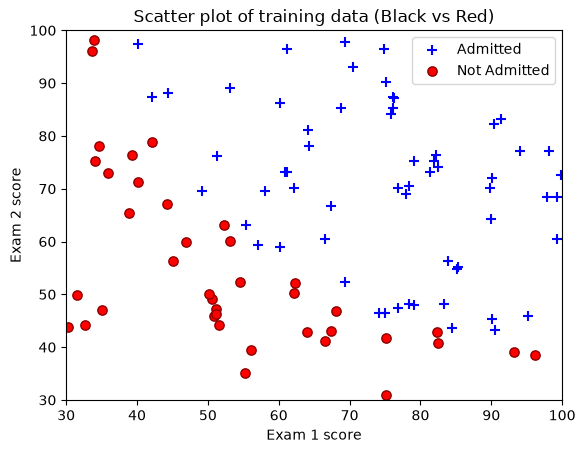

In [8]:
# creating a mask

admitted_mask = (y_train == 1)
not_admitted_mask = (y_train == 0)

# plotting
plt.scatter(X_train[admitted_mask, 0], X_train[admitted_mask, 1],
           marker = '+', color = 'b', s = 60, label = 'Admitted')
plt.scatter(X_train[not_admitted_mask, 0], X_train[not_admitted_mask, 1],
           marker = 'o', color = 'red', edgecolor = 'darkred', s = 45, label = 'Not Admitted')

plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.title('Scatter plot of training data (Black vs Red)')
plt.legend(loc='upper right')
plt.xlim(30, 100)
plt.ylim(30, 100)

plt.show()

In [29]:
def sigmoid(z):
    
    g = 1 / (1 + np.exp(-z))

    return g

In [10]:
print ("sigmoid(0) = " + str(sigmoid(0)))

sigmoid(0) = 0.5


In [11]:
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]


In [28]:
def compute_cost(X, y, w, b):
    
    m, n = X.shape
    cost = 0
    for i in range(m):
        z = np.dot(X[i], w) + b
        f_wb = sigmoid(z)
        cost += -y[i] * np.log(f_wb) - (1 - y [i]) * np.log(1 - f_wb)
    total_cost = cost / m
    return total_cost

In [13]:
m, n = X_train.shape

initial_w = np.zeros(n)
initial_b = 0
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


In [27]:
def compute_gradient(X, y, w, b):    
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0

    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err_i = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i, j]
        dj_db = dj_db + err_i

    dj_dw = dj_dw/m                                   
    dj_db = dj_db/m

    return dj_db, dj_dw

In [15]:
# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.11
dj_dw at initial w (zeros):[-12.5125, -10.943349999999999]


In [22]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    m = len(X)
    J_history = []
    w_history = []
    
    # We use a copy to avoid modifying the global variables directly
    w = copy.deepcopy(w_in)
    b = b_in
    
    for i in range(num_iters):
        # Calculate the gradient 
        dj_db, dj_dw = gradient_function(X, y, w, b)   

        # Update Parameters
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db              
       
        # Save cost J at each iteration
        if i < 100000:      
            cost = cost_function(X, y, w, b)
            J_history.append(cost)

        # Print cost at 10 intervals
        if i % math.ceil(num_iters / 10) == 0 or i == (num_iters - 1):
            w_history.append(w)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.3f}")
        
    return w, b, J_history, w_history

In [23]:
def predict(X, w, b): 
    # Calculate z for all examples at once (vectorized)
    z = np.dot(X, w) + b
    
    # Calculate probabilities
    f_wb = sigmoid(z)
    
    # Apply the threshold of 0.5 to create an array of 0s and 1s
    p = (f_wb >= 0.5).astype(int)
    
    return p

In [24]:
# Initialize parameters
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8.0  # Starting with a negative bias helps logistic regression on positive unscaled data

# Gradient descent settings
iterations = 10000
alpha = 0.001

# RUN GRADIENT DESCENT
w, b, J_history, _ = gradient_descent(X_train, y_train, initial_w, initial_b, 
                                      compute_cost, compute_gradient, alpha, iterations)

print(f"\nOptimized parameters: w: {w}, b: {b}")

Iteration    0: Cost    1.053
Iteration 1000: Cost    0.328
Iteration 2000: Cost    0.328
Iteration 3000: Cost    0.327
Iteration 4000: Cost    0.327
Iteration 5000: Cost    0.327
Iteration 6000: Cost    0.326
Iteration 7000: Cost    0.326
Iteration 8000: Cost    0.326
Iteration 9000: Cost    0.326
Iteration 9999: Cost    0.325

Optimized parameters: w: [0.07351052 0.06385716], b: -8.175158076742136


In [25]:
# Compute accuracy on our training set
p = predict(X_train, w, b)
accuracy = np.mean(p == y_train) * 100
print(f'Train Accuracy: {accuracy:.2f}%')

Train Accuracy: 90.00%


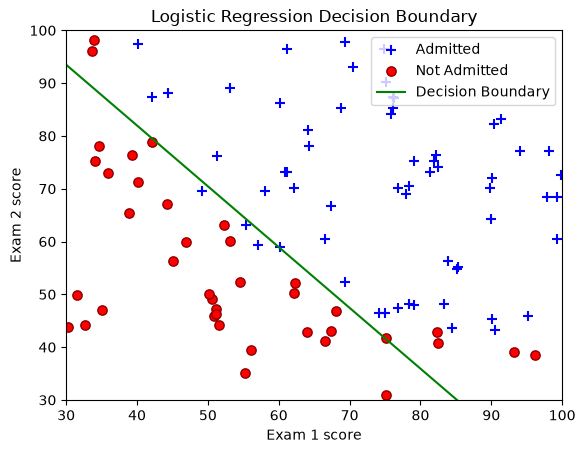

In [26]:
admitted_mask = (y_train == 1)
not_admitted_mask = (y_train == 0)

plt.scatter(X_train[admitted_mask, 0], X_train[admitted_mask, 1],
           marker='+', color='b', s=60, label='Admitted')
plt.scatter(X_train[not_admitted_mask, 0], X_train[not_admitted_mask, 1],
           marker='o', color='red', edgecolor='darkred', s=45, label='Not Admitted')

plot_x = np.array([min(X_train[:, 0]) - 2, max(X_train[:, 0]) + 2])

plot_y = (-b - w[0] * plot_x) / w[1]

plt.plot(plot_x, plot_y, c="green", label="Decision Boundary")

plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.title('Logistic Regression Decision Boundary')
plt.legend(loc='upper right')
plt.xlim(30, 100)
plt.ylim(30, 100)

plt.show()